In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('dark')

In [2]:
df = pd.read_pickle('weather_data.pkl')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           27 non-null     int64         
 1   location     27 non-null     object        
 2   time_stamp   27 non-null     datetime64[ns]
 3   temp_c       27 non-null     float64       
 4   humidity     27 non-null     int64         
 5   cond         27 non-null     object        
 6   wind_kph     27 non-null     float64       
 7   pressure_mb  27 non-null     float64       
 8   year         27 non-null     int32         
 9   month        27 non-null     int32         
 10  day          27 non-null     int32         
 11  hour         27 non-null     int32         
dtypes: datetime64[ns](1), float64(3), int32(4), int64(2), object(2)
memory usage: 2.2+ KB


In [3]:
df_ind = df.set_index('time_stamp')
df_ind

,id,location,temp_c,humidity,cond,wind_kph,pressure_mb,year,month,day,hour
time_stamp,,,,,,,,,,,
2025-08-10 22:54:00,14,Kristiansand,15.1,67,Overcast,18.4,1023.0,2025,8,10,22
2025-08-10 23:53:00,18,Kristiansand,14.3,72,Clear,17.6,1024.0,2025,8,10,23
2025-08-11 04:50:00,19,Kristiansand,13.3,77,Overcast,20.5,1023.0,2025,8,11,4
2025-08-11 05:39:00,20,Kristiansand,13.3,77,Cloudy,19.8,1023.0,2025,8,11,5
2025-08-11 05:54:00,21,Kristiansand,13.1,77,Cloudy,19.8,1023.0,2025,8,11,5
2025-08-11 06:53:00,22,Kristiansand,13.0,77,Partly Cloudy,19.8,1023.0,2025,8,11,6
2025-08-11 07:54:00,23,Kristiansand,12.1,88,Partly Cloudy,18.4,1023.0,2025,8,11,7
2025-08-11 08:51:00,24,Kristiansand,13.1,82,Cloudy,18.7,1022.0,2025,8,11,8
2025-08-11 12:28:00,25,Kristiansand,15.3,82,Light rain,20.9,1021.0,2025,8,11,12


In [4]:
df_ind.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 27 entries, 2025-08-10 22:54:00 to 2025-08-12 18:55:00
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           27 non-null     int64  
 1   location     27 non-null     object 
 2   temp_c       27 non-null     float64
 3   humidity     27 non-null     int64  
 4   cond         27 non-null     object 
 5   wind_kph     27 non-null     float64
 6   pressure_mb  27 non-null     float64
 7   year         27 non-null     int32  
 8   month        27 non-null     int32  
 9   day          27 non-null     int32  
 10  hour         27 non-null     int32  
dtypes: float64(3), int32(4), int64(2), object(2)
memory usage: 2.1+ KB


In [13]:
df['date_only'] = df['time_stamp'].dt.date

In [16]:
df.groupby('date_only')['temp_c'].max()

date_only
2025-08-10    15.1
2025-08-11    17.2
2025-08-12    20.3
Name: temp_c, dtype: float64

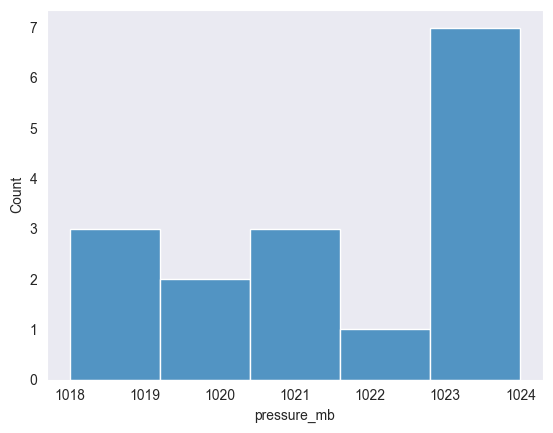

In [59]:
sns.histplot(df['pressure_mb']);

In [60]:
df_last = df.iloc[-1,1:]
df_last['pressure_mb']

np.float64(1018.0)

In [61]:
pressure_value = df_last['pressure_mb']


In [69]:
import plotly.graph_objects as go


fig2 = go.Figure()

fig2.add_annotation(
    text="⛅",
    x=0.5, y=0.5,
    showarrow=False,
    font=dict(size=100)
)

fig2.update_layout(
    width=200,
    height=100,
    xaxis=dict(visible=False),
    yaxis=dict(visible=False)
)

fig2.show()


fig = go.Figure(go.Indicator(
    mode = "gauge+number",
    value = pressure_value,
    title = {'text': "Barometer (mb)"},
    gauge = {
        'axis': {'range': [950, 1050]},
        'bar': {'color': "darkblue"},
        'steps': [
            {'range': [950, 980], 'color': "lightgray"},
            {'range': [980, 1020], 'color': "gray"},
            {'range': [1020, 1050], 'color': "lightgray"}
        ],
        'threshold': {
            'line': {'color': "red", 'width': 4},
            'thickness': 0.75,
            'value': 1025
        }
    }
))
fig.update_layout(
    width=400,
    height=300
)

fig.show()




In [68]:
df_last['cond_symbol']

KeyError: 'cond_symbol'

In [64]:
df['cond'].unique()

array(['Overcast', 'Clear', 'Cloudy', 'Partly Cloudy', 'Light rain',
       'Partly cloudy', 'Moderate rain'], dtype=object)

In [65]:
# Define your symbol map
symbol_map = {
    'Clear': '☀️',
    'Cloudy': '☁️',
    'Overcast': '🌥️',
    'Partly Cloudy': '⛅',
    'Partly cloudy': '⛅',
    'Light rain': '🌦️',
    'Moderate rain': '🌧️'
}

# Apply to a new column
df['cond_symbol'] = df['cond'].map(symbol_map)


In [66]:
import plotly.graph_objects as go

fig2 = go.Figure()

fig2.add_annotation(
    text="🌧️",
    x=0.5, y=0.5,
    showarrow=False,
    font=dict(size=100)
)

fig2.update_layout(
    width=200,
    height=100,
    xaxis=dict(visible=False),
    yaxis=dict(visible=False)
)

fig2.show()
